<a href="https://www.kaggle.com/code/mrrogueknight/dynamic-pricing-for-urban-parking-lots?scriptVersionId=248439609" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/capstoneproject/dataset.csv


# Dynamic Pricing for Urban Parking Lots 
---
Summer Analytics 2025

##  What's the Problem?

- Urban areas often face a parking crisis.
- Some parking lots are always overcrowded
- while others remain empty, even when nearby.
---
Why? 
- Because parking prices are static i.e. they don’t change based on
- How full a lot is
- How heavy the traffic is
- What type of vehicle is trying to enter
- Or if it’s a holiday/event day
---

## What’s the Goal?

- building an AI-powered dynamic pricing system that updates parking fees in real time for each of 14 parking lots so that:
- Prices increase when demand is high
- Prices drop to attract drivers when demand is low
- The system learns from real-world patterns

## What Does “Dynamic Pricing” Mean?

Like how Uber or airline tickets go up in peak hours, you’ll build a system where:
- Prices adjust every 30 minutes
- Based on real-time data (occupancy, traffic, etc.)
- Starting from a base price example of $10
This makes parking smarter, fairer, and better utilized.

## Visualization

We will use Bokeh to create real-time visualizations 
- Show how price changes per lot over time
- Compare prices between nearby parking lots

## Real-Time Simulation Using Pathway

Instead of reading data all at once, we'll simulate how data arrives in real time:

- One row at a time (like streaming data)
- Pricing must update as each new row comes in
- Pathway helps manage this simulation

## Library Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import bokeh.plotting as bp
from bokeh.io import output_notebook, show
output_notebook()

# Optional
import seaborn as sns

Loading BokehJS ...

## Data Loading & Exploration

In [3]:
df = pd.read_csv('/kaggle/input/capstoneproject/dataset.csv')

In [4]:
print(df.shape)

(18368, 12)


In [5]:
df.head()

,ID,SystemCodeNumber,Capacity,Latitude,Longitude,Occupancy,VehicleType,TrafficConditionNearby,QueueLength,IsSpecialDay,LastUpdatedDate,LastUpdatedTime
0,0,BHMBCCMKT01,577,26.144536,91.736172,61,car,low,1,0,04-10-2016,07:59:00
1,1,BHMBCCMKT01,577,26.144536,91.736172,64,car,low,1,0,04-10-2016,08:25:00
2,2,BHMBCCMKT01,577,26.144536,91.736172,80,car,low,2,0,04-10-2016,08:59:00
3,3,BHMBCCMKT01,577,26.144536,91.736172,107,car,low,2,0,04-10-2016,09:32:00
4,4,BHMBCCMKT01,577,26.144536,91.736172,150,bike,low,2,0,04-10-2016,09:59:00


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18368 entries, 0 to 18367
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      18368 non-null  int64  
 1   SystemCodeNumber        18368 non-null  object 
 2   Capacity                18368 non-null  int64  
 3   Latitude                18368 non-null  float64
 4   Longitude               18368 non-null  float64
 5   Occupancy               18368 non-null  int64  
 6   VehicleType             18368 non-null  object 
 7   TrafficConditionNearby  18368 non-null  object 
 8   QueueLength             18368 non-null  int64  
 9   IsSpecialDay            18368 non-null  int64  
 10  LastUpdatedDate         18368 non-null  object 
 11  LastUpdatedTime         18368 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 1.7+ MB


In [7]:
df.describe()

,ID,Capacity,Latitude,Longitude,Occupancy,QueueLength,IsSpecialDay
count,18368.000000,18368.000000,18368.000000,18368.000000,18368.000000,18368.000000,18368.000000
mean,9183.500000,1605.214286,25.706547,90.751170,731.084059,4.587925,0.150915
std,5302.529208,1131.153886,1.582749,3.536636,621.164982,2.580062,0.357975
min,0.000000,387.000000,20.000035,78.000003,2.000000,0.000000,0.000000
25%,4591.750000,577.000000,26.140048,91.727995,322.000000,2.000000,0.000000
50%,9183.500000,1261.000000,26.147482,91.729511,568.000000,4.000000,0.000000
75%,13775.250000,2803.000000,26.147541,91.736172,976.000000,6.000000,0.000000
max,18367.000000,3883.000000,26.150504,91.740994,3499.000000,15.000000,1.000000


# Model 1: Baseline Linear Model

## Formula:

$$
\text{Price}_{t+1} = \text{Price}_t + \alpha \times \left(\frac{\text{Occupancy}}{\text{Capacity}}\right)
$$

* Start with **Price = \$10**
* Use a fixed **α (alpha)** value (e.g., `0.3`) - Stable pricing for brand trust
* Ensure the price stays within reasonable bounds (e.g., `$5 to $20`)
* Calculate price **per lot**, sorted in time

In [10]:
# Combine date and time to create a timestamp
df['Timestamp'] = pd.to_datetime(
    df['LastUpdatedDate'] + ' ' + df['LastUpdatedTime'],
    format='%d-%m-%Y %H:%M:%S'
)

In [11]:
# Sort data by parking lot and time
df_sorted = df.sort_values(by=['SystemCodeNumber', 'Timestamp']).copy()

In [12]:
df_sorted

,ID,SystemCodeNumber,Capacity,Latitude,Longitude,Occupancy,VehicleType,TrafficConditionNearby,QueueLength,IsSpecialDay,LastUpdatedDate,LastUpdatedTime,Timestamp
0,0,BHMBCCMKT01,577,26.144536,91.736172,61,car,low,1,0,04-10-2016,07:59:00,2016-10-04 07:59:00
1,1,BHMBCCMKT01,577,26.144536,91.736172,64,car,low,1,0,04-10-2016,08:25:00,2016-10-04 08:25:00
2,2,BHMBCCMKT01,577,26.144536,91.736172,80,car,low,2,0,04-10-2016,08:59:00,2016-10-04 08:59:00
3,3,BHMBCCMKT01,577,26.144536,91.736172,107,car,low,2,0,04-10-2016,09:32:00,2016-10-04 09:32:00
4,4,BHMBCCMKT01,577,26.144536,91.736172,150,bike,low,2,0,04-10-2016,09:59:00,2016-10-04 09:59:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18363,18363,Shopping,1920,26.150504,91.733531,1517,truck,average,6,0,19-12-2016,14:30:00,2016-12-19 14:30:00
18364,18364,Shopping,1920,26.150504,91.733531,1487,car,low,3,0,19-12-2016,15:03:00,2016-12-19 15:03:00
18365,18365,Shopping,1920,26.150504,91.733531,1432,cycle,low,3,0,19-12-2016,15:29:00,2016-12-19 15:29:00
18366,18366,Shopping,1920,26.150504,91.733531,1321,car,low,2,0,19-12-2016,16:03:00,2016-12-19 16:03:00


In [14]:
# Set pricing parameters
alpha = 0.3 # slow, stable, profit-friendly
base_price = 10.0
min_price = 5.0
max_price = 20.0

In [15]:
# Apply pricing logic per parking lot
baseline_prices = []

In [17]:
for lot_id, lot_data in df_sorted.groupby('SystemCodeNumber'):
    price = base_price
    lot_prices = []

    for _, row in lot_data.iterrows():
        occupancy_ratio = row['Occupancy'] / row['Capacity']
        price += alpha * occupancy_ratio
        price = max(min_price, min(price, max_price))
        lot_prices.append(price)

    baseline_prices.extend(lot_prices)

In [18]:
# Add BaselinePrice to your dataframe
df_sorted['BaselinePrice'] = baseline_prices

In [24]:
# Step 6: Preview the results
df_sorted[['SystemCodeNumber', 'Timestamp', 'Occupancy', 'Capacity', 'BaselinePrice']].head(10)

,SystemCodeNumber,Timestamp,Occupancy,Capacity,BaselinePrice
0,BHMBCCMKT01,2016-10-04 07:59:00,61,577,10.031716
1,BHMBCCMKT01,2016-10-04 08:25:00,64,577,10.064991
2,BHMBCCMKT01,2016-10-04 08:59:00,80,577,10.106586
3,BHMBCCMKT01,2016-10-04 09:32:00,107,577,10.162218
4,BHMBCCMKT01,2016-10-04 09:59:00,150,577,10.240208
5,BHMBCCMKT01,2016-10-04 10:26:00,177,577,10.332236
6,BHMBCCMKT01,2016-10-04 10:59:00,219,577,10.446101
7,BHMBCCMKT01,2016-10-04 11:25:00,247,577,10.574523
8,BHMBCCMKT01,2016-10-04 11:59:00,259,577,10.709185
9,BHMBCCMKT01,2016-10-04 12:29:00,266,577,10.847487


In [26]:
# Filter for a single parking lot
first_lot = df_sorted['SystemCodeNumber'].unique()[0]
df_lot = df_sorted[df_sorted['SystemCodeNumber'] == first_lot]

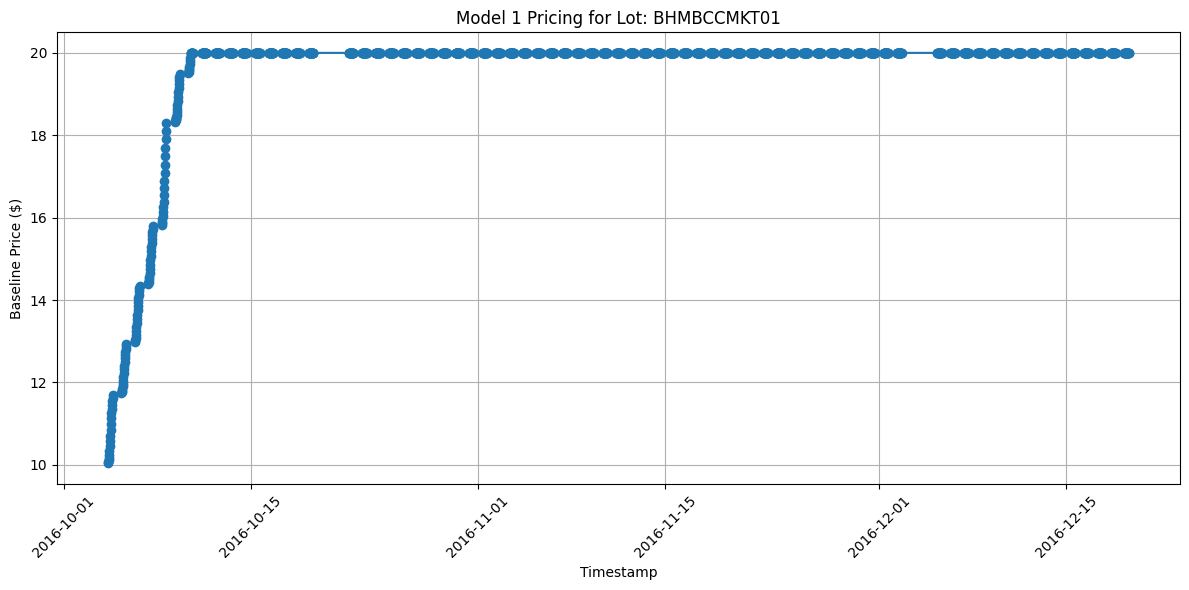

In [27]:
# Plot price over time
plt.figure(figsize=(12, 6))
plt.plot(df_lot['Timestamp'], df_lot['BaselinePrice'], marker='o', linestyle='-')
plt.title(f"Model 1 Pricing for Lot: {first_lot}")
plt.xlabel("Timestamp")
plt.ylabel("Baseline Price ($)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Bokeh

In [28]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource
from bokeh.layouts import layout

In [29]:
output_notebook()

Loading BokehJS ...

In [30]:
source = ColumnDataSource(df_lot)

In [34]:
p = figure(x_axis_type='datetime', title=f"Model 1 Pricing for Lot: {first_lot}",
           width=900, height=400)
p.line('Timestamp', 'BaselinePrice', source=source, line_width=2, color='navy', legend_label="Baseline Price")
p.scatter('Timestamp', 'BaselinePrice', source=source, size=5, color='red') 
# Changed circle() to scatter()

GlyphRenderer(id='p1275', ...)

In [35]:
# Style plot
p.xaxis.axis_label = 'Time'
p.yaxis.axis_label = 'Price ($)'
p.legend.location = 'top_left'
p.grid.grid_line_alpha = 0.3

In [36]:
show(p)

## Compare Pricing for Multiple Parking Lots

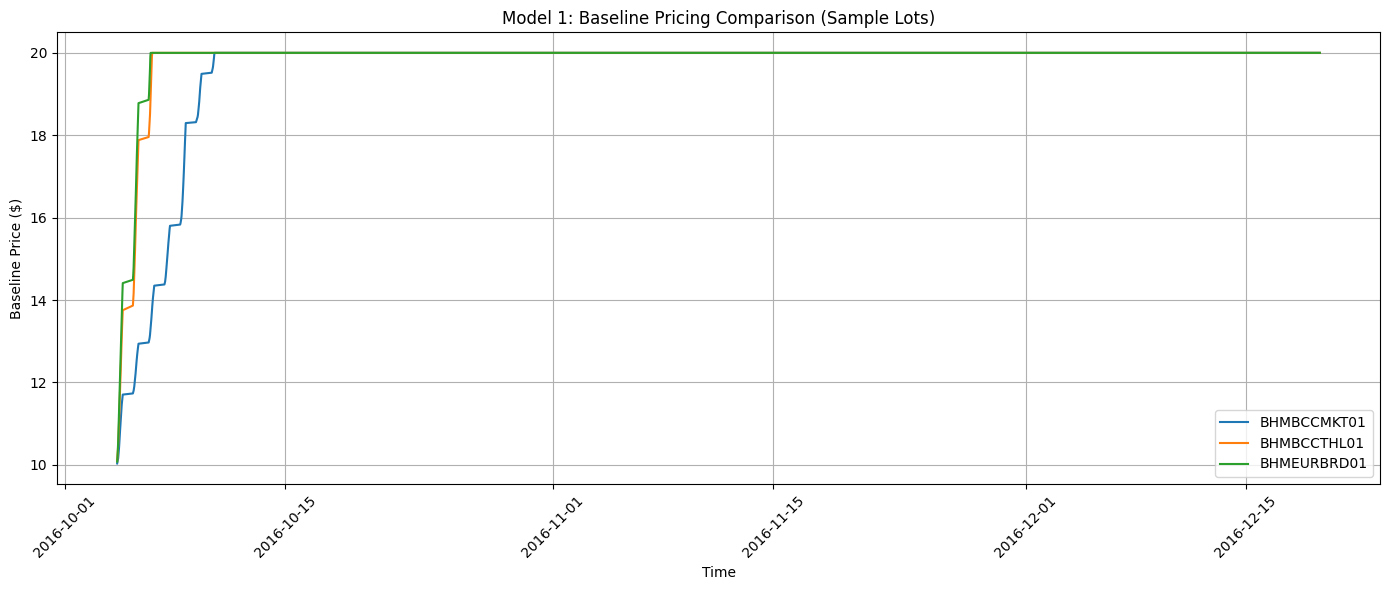

In [42]:
sample_lots = df_sorted['SystemCodeNumber'].unique()[:3]

plt.figure(figsize=(14, 6))

for lot in sample_lots:
    lot_data = df_sorted[df_sorted['SystemCodeNumber'] == lot]
    plt.plot(lot_data['Timestamp'], lot_data['BaselinePrice'], label=lot)

plt.title("Model 1: Baseline Pricing Comparison (Sample Lots)")
plt.xlabel("Time")
plt.ylabel("Baseline Price ($)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Estimate Revenue per Row

Since:

$$
\text{Revenue}_t = \text{Occupancy}_t \times \text{Price}_t
$$

We can add a `Revenue` column for each row using `BaselinePrice`.



In [43]:
# Calculate revenue per row
df_sorted['Revenue'] = df_sorted['Occupancy'] * df_sorted['BaselinePrice']

In [44]:
# Preview updated DataFrame
df_sorted[['SystemCodeNumber', 'Timestamp', 'Occupancy', 'BaselinePrice', 'Revenue']].head(10)

,SystemCodeNumber,Timestamp,Occupancy,BaselinePrice,Revenue
0,BHMBCCMKT01,2016-10-04 07:59:00,61,10.031716,611.934662
1,BHMBCCMKT01,2016-10-04 08:25:00,64,10.064991,644.159445
2,BHMBCCMKT01,2016-10-04 08:59:00,80,10.106586,808.526863
3,BHMBCCMKT01,2016-10-04 09:32:00,107,10.162218,1087.357366
4,BHMBCCMKT01,2016-10-04 09:59:00,150,10.240208,1536.031196
5,BHMBCCMKT01,2016-10-04 10:26:00,177,10.332236,1828.805719
6,BHMBCCMKT01,2016-10-04 10:59:00,219,10.446101,2287.696014
7,BHMBCCMKT01,2016-10-04 11:25:00,247,10.574523,2611.907279
8,BHMBCCMKT01,2016-10-04 11:59:00,259,10.709185,2773.679029
9,BHMBCCMKT01,2016-10-04 12:29:00,266,10.847487,2885.431542


In [46]:
# Select relevant columns
model1_output = df_sorted[['SystemCodeNumber', 'Timestamp', 'Occupancy', 'Capacity', 'BaselinePrice', 'Revenue']]

In [47]:
# Save to CSV
model1_output.to_csv("model1_baseline_pricing_output.csv", index=False)

# Summary Documentation Cell for Model 1

### Model 1: Baseline Linear Pricing

#### Objective:

To create a simple pricing model where the parking price increases **linearly** with **occupancy**, simulating basic economic behavior (high demand → higher price).

#### Formula:

$$
\text{Price}_{t+1} = \text{Price}_t + \alpha \times \left(\frac{\text{Occupancy}}{\text{Capacity}}\right)
$$

* **Base Price:** \$10.00
* **Alpha (α):** 0.3 *(slow and profit-focused)*
* **Clipping Range:** \$5.00 to \$20.00

  * Prevents unrealistic price surges or underpricing

---

#### Assumptions:

* Occupancy ratio directly reflects real-time demand.
* Price updates are **smooth and gradual** (not erratic).
* External features like traffic and queue are **not** used in this model (reserved for Model 2).
* Occupancy data is assumed to be accurate and synced in time.

---

#### Implementation Highlights:

* Prices are calculated **per lot** and **over time** using a rolling update.
* Price is clipped between \$5 and \$20 to maintain economic realism.
* Revenue is calculated as:

$$
\text{Revenue}_t = \text{BaselinePrice}_t \times \text{Occupancy}_t
$$

---

#### Outputs:

* Column: `BaselinePrice` — dynamically updated price
* Column: `Revenue` — estimated revenue at each time step
* Visualization: Price trend vs time (per lot)
* File: `model1_baseline_pricing_output.csv` — cleaned output

---